In [83]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
from featuregraph.behaviors.transition2 import Transition

from featuregraph.operators.states import (
    rising_state,
    stable_state,
)

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python: /usr/local/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [84]:
bit = [{"state": "stable", "target": 1.0, "duration": 40},
    {"state": "falling", "target": 0.2, "duration": 1},
    {"state": "stable", "target": 0.2, "duration": 20},
    {"state": "rising", "target": 1.0, "duration": 1},]
segments = []
for i in range(10):
    segments.extend([b for b in bit])

pulse = fg.datasets.pulse(
    segments,
    initial_value=1.0,
    sample_interval=0.01,
    signal_name="pulse",
)

In [85]:
pulse_transition = Transition(
    pulse,
    signal='pulse',
    direction='stable',
    op=stable_state,
)

df = pulse_transition.df

In [87]:
df['pulse_stable'].value_counts()

pulse_stable
True     599
False     21
Name: count, dtype: int64

(<Figure size 1600x880 with 4 Axes>,
 array([<Axes: ylabel='pulse'>, <Axes: ylabel='pulse_stable'>,
        <Axes: ylabel='enter_pulse_stable'>,
        <Axes: xlabel='Time', ylabel='pulse_stable_rate_of_change'>],
       dtype=object))

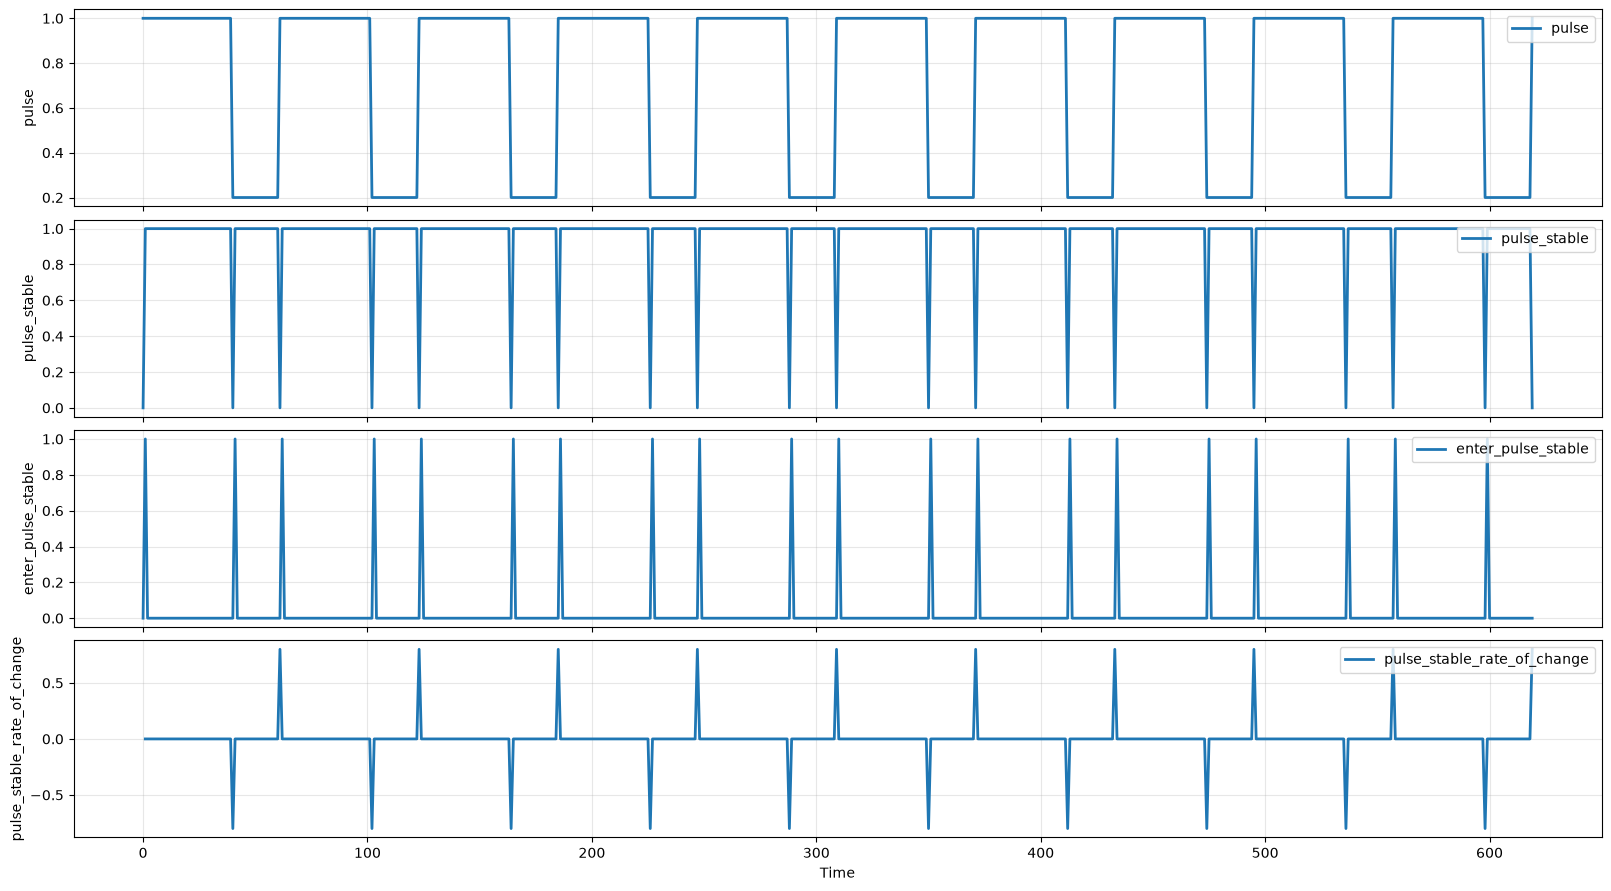

In [88]:
fg.plot(df, [['pulse'],
                ['pulse_stable'],
                ['enter_pulse_stable'],
                ['pulse_stable_rate_of_change']])

In [89]:
summarydf = pulse_transition.summary()

In [90]:
summarydf

,duration,start_value,end_value,peak_rate_of_change,net_change,mean_rate
pulse_id,,,,,,
0,0,1.0,1.0,NaN,0.0,NaN
1,39,1.0,0.2,0.0,-0.8,-0.020513
2,20,0.2,1.0,0.8,0.8,0.040000
3,40,1.0,0.2,0.0,-0.8,-0.020000
4,20,0.2,1.0,0.8,0.8,0.040000
5,40,1.0,0.2,0.0,-0.8,-0.020000
6,20,0.2,1.0,0.8,0.8,0.040000
7,40,1.0,0.2,0.0,-0.8,-0.020000
8,20,0.2,1.0,0.8,0.8,0.040000
